In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %% [markdown]
# # AdaBoost Scaling Experiment
# **Experiment 2**: Vary n_estimators from 1 to 200 and observe performance
# **Datasets**: Breast Cancer, Adult Income, Covertype, MNIST (Full - 10 classes)

# %%
import time

t1 = time.perf_counter()

In [3]:
# %%
# ==============================================================================
# ADA BOOST SCALING EXPERIMENT - STAGED APPROACH (OPTIMIZED WITH STAGED AUC)
# Experiment 2: Vary n_estimators from 1 to 200
# ==============================================================================

import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to path so local src packages are discoverable
sys.path.append("..")

from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data,
)

# Import our updated experiment utilities (handling staged predictions & probabilities)
from src.utils.adaboost_scale_experiment_utils import (
    get_memory_usage,
    run_all_staged,
    compare_with_sklearn,
)

# Set plotting style
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("=" * 60)
print("ADA BOOST SCALING EXPERIMENT - STAGED APPROACH (WITH AUC TRACKING)")
print("=" * 60)

ADA BOOST SCALING EXPERIMENT - STAGED APPROACH (WITH AUC TRACKING)


In [4]:
# %%
# ==============================================================================
# EXPERIMENT CONFIGURATION
# ==============================================================================
CONFIG = {
    "max_estimators": 200,  # Maximum number of estimators
    "step": 1,  # Record metric values at every step
    "test_size": 0.2,  # Train/test split ratio
    "random_state": 42,  # Fixed seed for reproducibility
    "sklearn_n_estimators": 200,  # Estimators to train for validation check
    "covertype_sample_size": None,  # Set an integer (e.g., 20000) if you want to speed up Covertype
    "mnist_sample_size": None,  # Set an integer (e.g., 10000) if you want to speed up MNIST
}

# Extract configuration values
MAX_ESTIMATORS = CONFIG["max_estimators"]
STEP = CONFIG["step"]
TEST_SIZE = CONFIG["test_size"]
RANDOM_STATE = CONFIG["random_state"]
SKLEARN_N_ESTIMATORS = CONFIG["sklearn_n_estimators"]
COVERTYPE_SAMPLE_SIZE = CONFIG.get("covertype_sample_size")
MNIST_SAMPLE_SIZE = CONFIG.get("mnist_sample_size")

# Create evaluation step markers
N_ESTIMATORS_LIST = sorted(list(set([1] + list(range(STEP, MAX_ESTIMATORS + 1, STEP)))))

print("\n" + "=" * 60)
print("EXPERIMENT CONFIGURATION LOADED")
print("=" * 60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(
    f"\n  Recording performance points: {N_ESTIMATORS_LIST[:10]}...{N_ESTIMATORS_LIST[-5:]}"
)
print("=" * 60)


EXPERIMENT CONFIGURATION LOADED
  max_estimators: 200
  step: 1
  test_size: 0.2
  random_state: 42
  sklearn_n_estimators: 200
  covertype_sample_size: None
  mnist_sample_size: None

  Recording performance points: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...[196, 197, 198, 199, 200]


In [5]:
# %%
# ==============================================================================
# LOAD DATASETS
# ==============================================================================
memory_stats = []

# 1. Load Breast Cancer
X_bc, y_bc, _ = load_breast_cancer_data(optimize_memory=True, verbose=False)
memory_stats.append(
    {
        "Dataset": "Breast_Cancer",
        "X_memory_mb": get_memory_usage(X_bc),
        "y_memory_mb": get_memory_usage(y_bc),
        "X_type": type(X_bc).__name__,
    }
)

# 2. Load Adult Income
X_adult, y_adult, _ = load_adult_income_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)
y_adult_binary = (y_adult.str.replace(".", "", regex=False) == ">50K").astype(int)
memory_stats.append(
    {
        "Dataset": "Adult_Income",
        "X_memory_mb": get_memory_usage(X_adult),
        "y_memory_mb": get_memory_usage(y_adult_binary),
        "X_type": type(X_adult).__name__,
    }
)

# 3. Load Covertype (with conditional subsampling)
X_cover, y_cover, _ = load_covertype_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)
if COVERTYPE_SAMPLE_SIZE is not None and COVERTYPE_SAMPLE_SIZE < len(X_cover):
    print(
        f"  Subsampling Covertype: {len(X_cover):,} → {COVERTYPE_SAMPLE_SIZE:,} samples"
    )
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_cover), COVERTYPE_SAMPLE_SIZE, replace=False
    )
    X_cover = X_cover.iloc[sample_indices]
    y_cover = y_cover.iloc[sample_indices]
else:
    print(f"  Using full Covertype dataset: {len(X_cover):,} samples")

y_cover_flat = y_cover.values.ravel()
memory_stats.append(
    {
        "Dataset": "Covertype",
        "X_memory_mb": get_memory_usage(X_cover),
        "y_memory_mb": get_memory_usage(y_cover),
        "X_type": type(X_cover).__name__,
    }
)

# 4. Load MNIST (with conditional subsampling)
X_mnist, y_mnist, _ = load_mnist_data(
    optimize_memory=True, verbose=False, return_numpy=False
)
if MNIST_SAMPLE_SIZE is not None and MNIST_SAMPLE_SIZE < len(X_mnist):
    print(f"  Subsampling MNIST: {len(X_mnist):,} → {MNIST_SAMPLE_SIZE:,} samples")
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_mnist), MNIST_SAMPLE_SIZE, replace=False
    )
    X_mnist = X_mnist.iloc[sample_indices]
    y_mnist = y_mnist.iloc[sample_indices]
else:
    print(f"  Using full MNIST dataset: {len(X_mnist):,} samples")

memory_stats.append(
    {
        "Dataset": "MNIST",
        "X_memory_mb": get_memory_usage(X_mnist),
        "y_memory_mb": get_memory_usage(y_mnist),
        "X_type": type(X_mnist).__name__,
    }
)

# Compile into our runtime datasets map
datasets = {
    "Breast_Cancer": (X_bc.values, y_bc.values),
    "Adult_Income": (X_adult.values, y_adult_binary.values),
    "Covertype": (X_cover.values, y_cover_flat),
    "MNIST": (X_mnist, y_mnist),
}

print("\n" + "=" * 60)
print("DATASETS LOADED SUCCESSFULLY")
print("=" * 60)
total_memory = 0.0
for entry in memory_stats:
    name = entry["Dataset"]
    ds_X, ds_y = datasets[name]
    x_mem = entry["X_memory_mb"]
    y_mem = entry["y_memory_mb"]
    total_memory += x_mem + y_mem
    print(
        f"  {name:15s} | Shape: {str(ds_X.shape):18s} | Classes: {len(np.unique(ds_y))} | Combined RAM: {x_mem + y_mem:6.2f} MB"
    )
print("-" * 60)
print(f"  Total RAM occupied by datasets: {total_memory:.2f} MB")
print("=" * 60)

  Using full Covertype dataset: 581,012 samples
  Using full MNIST dataset: 70,000 samples

DATASETS LOADED SUCCESSFULLY
  Breast_Cancer   | Shape: (569, 30)          | Classes: 2 | Combined RAM:   0.13 MB
  Adult_Income    | Shape: (48842, 6)         | Classes: 2 | Combined RAM:   2.61 MB
  Covertype       | Shape: (581012, 10)       | Classes: 7 | Combined RAM:  48.76 MB
  MNIST           | Shape: (70000, 784)       | Classes: 10 | Combined RAM: 419.24 MB
------------------------------------------------------------
  Total RAM occupied by datasets: 470.74 MB


In [6]:
# %%
# ==============================================================================
# RUN EXPORT EXPERIMENT PIPELINE
# ==============================================================================
print("Running AdaBoost scaling experiment (optimized staged evaluation)...")
t_start = time.perf_counter()

# Calls the utility script which leverages model persistence and saves CSV results
results, trained_models, total_fit_and_extraction_time = run_all_staged(
    datasets,
    max_estimators=MAX_ESTIMATORS,
    step=STEP,
    random_state=RANDOM_STATE,
    test_size=TEST_SIZE,
)

t_end = time.perf_counter()
print(
    f"\n[Execution Summary] Total runtime in this session: {t_end - t_start:.2f} seconds."
)

Running AdaBoost scaling experiment (optimized staged evaluation)...

Running AdaBoost scaling with n_estimators: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199


GENERATING GRAPHICAL PLOTS

Generating plots for Breast_Cancer...
  👉 Saved metric plot to: ../figures/adaboost_scaling_Breast_Cancer_full_metrics.png


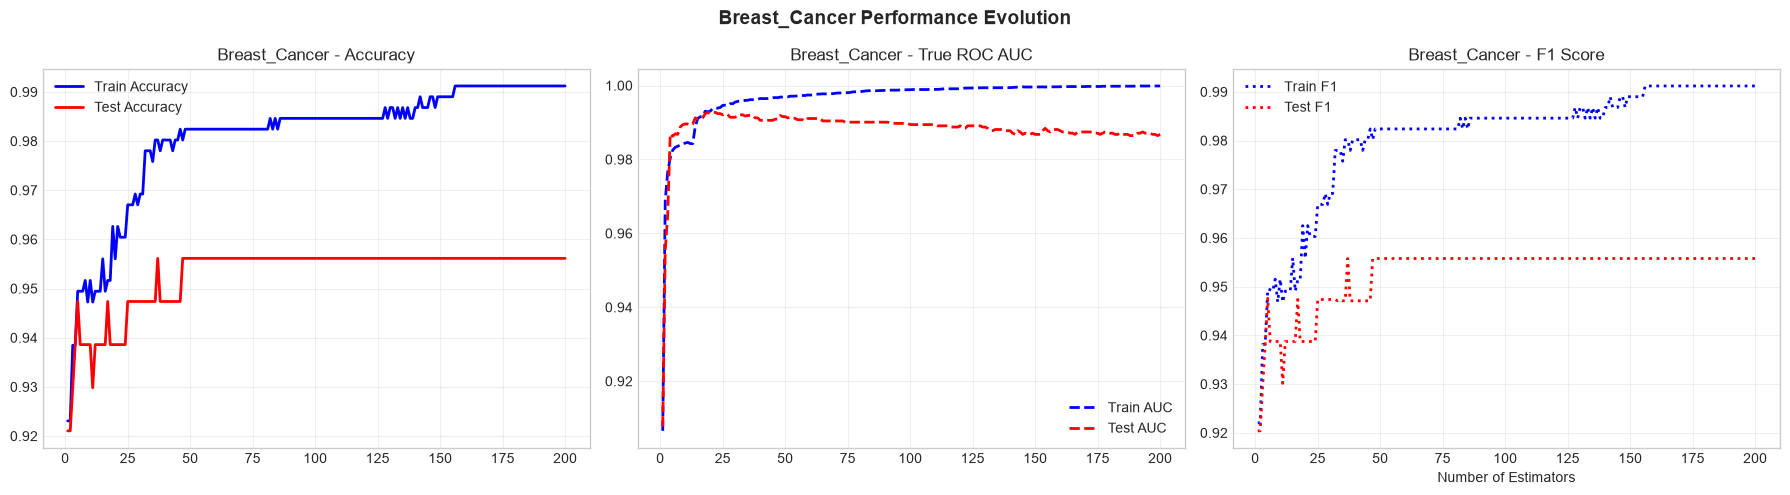


Generating plots for Adult_Income...
  👉 Saved metric plot to: ../figures/adaboost_scaling_Adult_Income_full_metrics.png


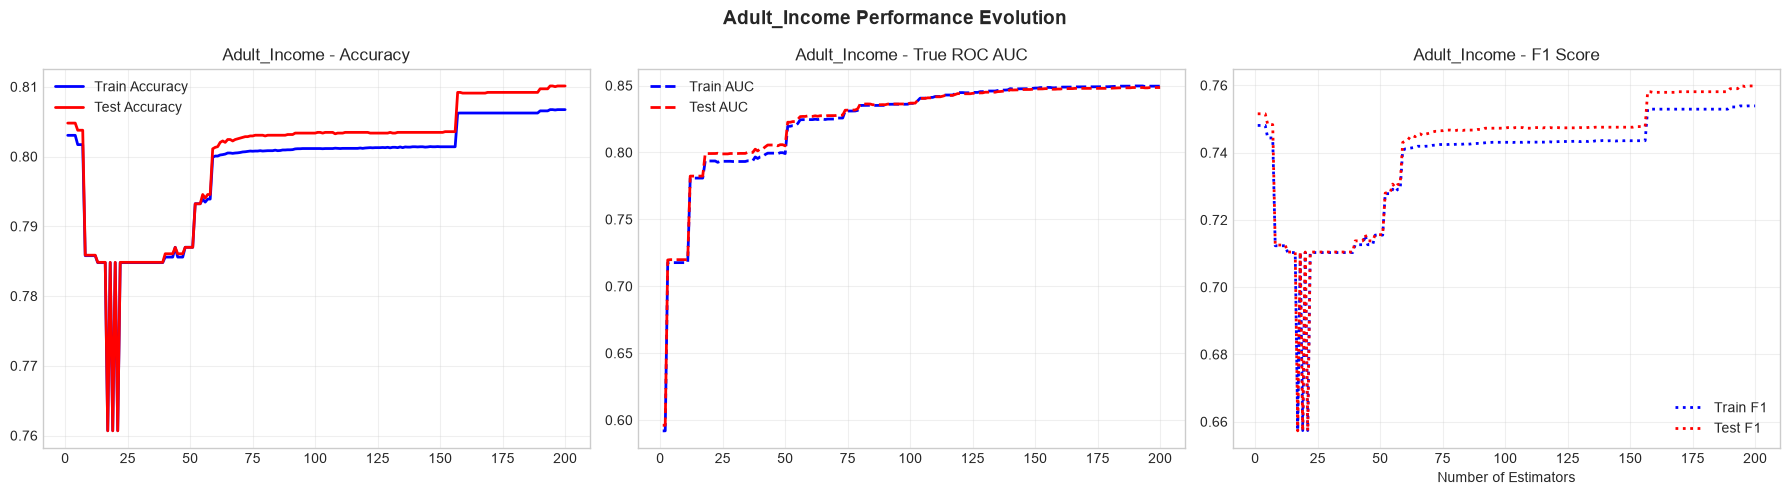


Generating plots for Covertype...
  👉 Saved metric plot to: ../figures/adaboost_scaling_Covertype_full_metrics.png


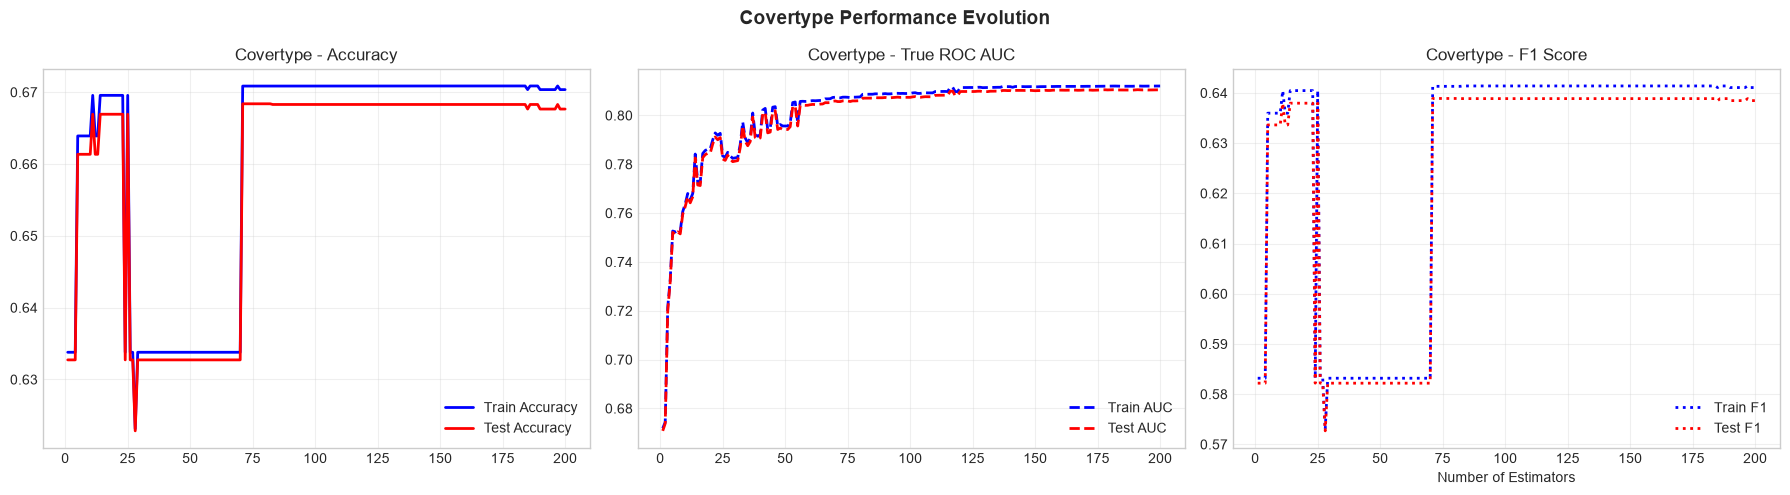


Generating plots for MNIST...
  👉 Saved metric plot to: ../figures/adaboost_scaling_MNIST_full_metrics.png


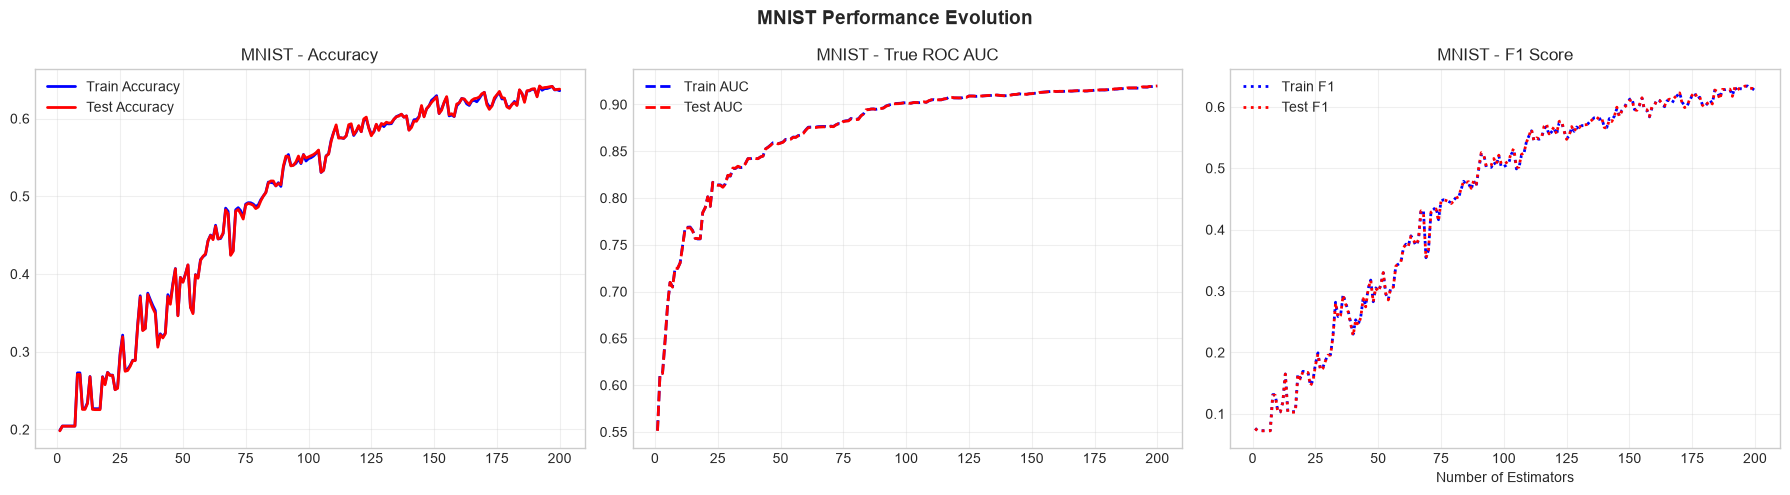

In [7]:
# %%
# ==============================================================================
# GENERATE PERFORMANCE PLOTS (ACCURACY & ROC AUC)
# ==============================================================================
print("\n" + "=" * 60)
print("GENERATING GRAPHICAL PLOTS")
print("=" * 60)

for name, result in results.items():
    print(f"\nGenerating plots for {name}...")

    # Increase figsize to 18x5 to accommodate 3 plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    n_estimators = result["n_estimators"]

    # 1. Left: Accuracy
    axes[0].plot(
        n_estimators, result["train_acc"], "b-", label="Train Accuracy", linewidth=2
    )
    axes[0].plot(
        n_estimators, result["test_acc"], "r-", label="Test Accuracy", linewidth=2
    )
    axes[0].set_title(f"{name} - Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Middle: ROC AUC
    axes[1].plot(
        n_estimators, result["train_auc"], "b--", label="Train AUC", linewidth=2
    )
    axes[1].plot(n_estimators, result["test_auc"], "r--", label="Test AUC", linewidth=2)
    axes[1].set_title(f"{name} - True ROC AUC")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3. Right: F1 Score (New!)
    axes[2].plot(n_estimators, result["train_f1"], "b:", label="Train F1", linewidth=2)
    axes[2].plot(n_estimators, result["test_f1"], "r:", label="Test F1", linewidth=2)
    axes[2].set_xlabel("Number of Estimators")
    axes[2].set_title(f"{name} - F1 Score")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f"{name} Performance Evolution", fontsize=14, weight="bold")
    plt.tight_layout()

    # Save with updated filename
    figure_path = f"../figures/adaboost_scaling_{name}_full_metrics.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    print(f"  👉 Saved metric plot to: {figure_path}")
    plt.show()

In [8]:
# %%
# ==============================================================================
# COMPILE EXPERIMENT METRICS & OVERFITTING SUMMARY
# ==============================================================================
summary_list = []

for name, result in results.items():
    best_idx = np.argmax(result["test_acc"])
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])
    gap = train_acc - test_acc

    if name == "Covertype":
        sample_size = (
            COVERTYPE_SAMPLE_SIZE
            if COVERTYPE_SAMPLE_SIZE is not None
            else len(datasets[name][0])
        )
    elif name == "MNIST":
        sample_size = (
            MNIST_SAMPLE_SIZE
            if MNIST_SAMPLE_SIZE is not None
            else len(datasets[name][0])
        )
    else:
        sample_size = len(datasets[name][0])

    summary_list.append(
        {
            "Dataset": name,
            "Sample Size": sample_size,
            "Best n_estimators": result["n_estimators"][best_idx],
            "Best Test Accuracy": result["test_acc"][best_idx],
            "Best Test F1": result["test_f1"][best_idx],
            "Best Test AUC": result["test_auc"][best_idx],
            "Final Test Accuracy": result["test_acc"][-1],
            "Train-Test Gap": gap[-1],
            "Max Overfitting Gap": max(gap),
            "Number of Classes": len(np.unique(datasets[name][1])),
        }
    )

# Formulate best_df smoothly to support down-stream print statements
best_df = pd.DataFrame(summary_list)

print("\n" + "=" * 80)
print("EXPERIMENT RUNNER PERFORMANCE SUMMARY")
print("=" * 80)
print(best_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 80)

# Save summarized run to CSV
summary_csv_path = "../notebooks/adaboost_scaling_with_auc_summary.csv"
os.makedirs(os.path.dirname(summary_csv_path), exist_ok=True)
best_df.to_csv(summary_csv_path, index=False)
print(f"Summary performance records saved to: {summary_csv_path}")


EXPERIMENT RUNNER PERFORMANCE SUMMARY
      Dataset  Sample Size  Best n_estimators  Best Test Accuracy  Best Test F1  Best Test AUC  Final Test Accuracy  Train-Test Gap  Max Overfitting Gap  Number of Classes
Breast_Cancer          569                 37              0.9561        0.9558         0.9919               0.9561          0.0351               0.0351                  2
 Adult_Income        48842                194              0.8101        0.7598         0.8483               0.8101         -0.0034               0.0001                  2
    Covertype       581012                 71              0.6684        0.6389         0.8057               0.6677          0.0027               0.0027                  7
        MNIST        70000                192              0.6419        0.6325         0.9178               0.6379         -0.0021               0.0039                 10
Summary performance records saved to: ../notebooks/adaboost_scaling_with_auc_summary.csv


In [9]:
# %%
# ==============================================================================
# VALIDATION: COMPARISON WITH SCIKIT-LEARN
# ==============================================================================
print("\n" + "=" * 60)
print("SCIKIT-LEARN ADABOOST VALIDATION")
print("=" * 60)

comparison_results = []
for name, (X, y) in datasets.items():
    print(f"Testing {name} implementation equivalence...")
    model = trained_models[name]

    our_acc, sk_acc = compare_with_sklearn(
        model, X, y, name, random_state=RANDOM_STATE, test_size=TEST_SIZE
    )
    diff = abs(our_acc - sk_acc)
    passed = diff < 0.02

    comparison_results.append(
        {
            "Dataset": name,
            "Our Accuracy": our_acc,
            "sklearn Accuracy": sk_acc,
            "Difference": diff,
            "Pass": passed,
        }
    )

comparison_df = pd.DataFrame(comparison_results)
print("\n" + "=" * 60)
print("VALIDATION MATRIX SUMMARY")
print("=" * 60)
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("=" * 60)


SCIKIT-LEARN ADABOOST VALIDATION
Testing Breast_Cancer implementation equivalence...
  Breast_Cancer: Our=0.9561, sklearn=0.9561, diff=0.0000
Testing Adult_Income implementation equivalence...
  Adult_Income: Our=0.8101, sklearn=0.8101, diff=0.0000
Testing Covertype implementation equivalence...
  Covertype: Our=0.6677, sklearn=0.6677, diff=0.0000
Testing MNIST implementation equivalence...
  MNIST: Our=0.6379, sklearn=0.6379, diff=0.0000

VALIDATION MATRIX SUMMARY
      Dataset  Our Accuracy  sklearn Accuracy  Difference  Pass
Breast_Cancer      0.956140          0.956140    0.000000  True
 Adult_Income      0.810114          0.810114    0.000000  True
    Covertype      0.667651          0.667651    0.000000  True
        MNIST      0.637857          0.637857    0.000000  True


In [10]:
# %%
# ==============================================================================
# FINAL METRICS & FINDINGS PRINT
# ==============================================================================
print("\nDATASETS SUMMARY")
print("-" * 40)
for name, (X, y) in datasets.items():
    if name == "Covertype":
        sample_size = (
            COVERTYPE_SAMPLE_SIZE if COVERTYPE_SAMPLE_SIZE is not None else X.shape[0]
        )
        full_size = X.shape[0]
    elif name == "MNIST":
        sample_size = MNIST_SAMPLE_SIZE if MNIST_SAMPLE_SIZE is not None else X.shape[0]
        full_size = X.shape[0]
    else:
        sample_size = X.shape[0]
        full_size = X.shape[0]

    print(f"  {name}:")
    if name in ["Covertype", "MNIST"] and sample_size != full_size:
        print(f"    Samples: {sample_size:,} (subsampled from {full_size:,})")
    else:
        print(f"    Samples: {sample_size:,}")
    print(f"    Features: {X.shape[1]}")
    print(f"    Classes: {len(np.unique(y))}")
    if len(np.unique(y)) <= 10:
        print(f"    Class distribution: {np.bincount(y.astype(int))}")

print("\nBEST RESULTS PER DATASET")
print("-" * 40)
print(best_df.to_string(index=False))

print("\nKEY FINDINGS")
print("-" * 40)
best_row = best_df.loc[best_df["Best Test Accuracy"].idxmax()]
print(f"  Best Overall Accuracy: {best_row['Dataset']}")
print(f"     Accuracy: {best_row['Best Test Accuracy']:.4f}")
print(f"     n_estimators: {best_row['Best n_estimators']}")

best_f1_row = best_df.loc[best_df["Best Test F1"].idxmax()]
print(f"\n  Best Overall F1: {best_f1_row['Dataset']}")
print(f"     F1: {best_f1_row['Best Test F1']:.4f}")
print(f"     n_estimators: {best_f1_row['Best n_estimators']}")

print("\n  Overfitting Analysis:")
for _, row in best_df.iterrows():
    gap = row["Max Overfitting Gap"]
    status = "Low" if gap < 0.02 else "Moderate" if gap < 0.05 else "High"
    print(f"    {row['Dataset']}: Max gap = {gap:.4f} ({status})")

print("\n  sklearn Validation:")
for _, row in comparison_df.iterrows():
    status = "Pass" if row["Pass"] else "Fail"
    print(f"    {row['Dataset']}: Diff = {row['Difference']:.4f} ({status})")

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)


DATASETS SUMMARY
----------------------------------------
  Breast_Cancer:
    Samples: 569
    Features: 30
    Classes: 2
    Class distribution: [212 357]
  Adult_Income:
    Samples: 48,842
    Features: 6
    Classes: 2
    Class distribution: [37155 11687]
  Covertype:
    Samples: 581,012
    Features: 10
    Classes: 7
    Class distribution: [     0 211840 283301  35754   2747   9493  17367  20510]
  MNIST:
    Samples: 70,000
    Features: 784
    Classes: 10
    Class distribution: [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]

BEST RESULTS PER DATASET
----------------------------------------
      Dataset  Sample Size  Best n_estimators  Best Test Accuracy  Best Test F1  Best Test AUC  Final Test Accuracy  Train-Test Gap  Max Overfitting Gap  Number of Classes
Breast_Cancer          569                 37            0.956140      0.955776       0.991898             0.956140        0.035068             0.035068                  2
 Adult_Income        48842            

In [11]:
# %%
t2 = time.perf_counter()
print(f"notebook took {t2 - t1:.2f} seconds to run")

notebook took 797.06 seconds to run
